# Bayesian Optimisation for Membrane / CHOL values — Yield & Biomass Productivity

Three surrogate models are compared:
- **ModelListGP**: two independent GPs (one per output), standard BoTorch baseline
- **MTGP**: `MultiTaskGP` (ICM coregionalization) — captures output correlation
- **RandomForest**: sklearn RF wrapped as a BoTorch-compatible model using tree-ensemble variance as proxy uncertainty

Each model runs **batch BO** ($q=3$) via `qNEHVI` (for GPs) and a `qNEI`-analogue for the RF wrapper.

**Inputs**: `thickness`, `density`, `porosity`, `CHOL_input`
**Outputs**: `yield` (maximize), `biomass_productivity` (maximize)

Every observation comes with a reported experimental standard deviation
(`yield_SD`, `biomass_productivity_SD`). This notebook shows tries to fold that *known, heteroscedastic*
measurement noise into all three surrogates, instead of ignoring it or having the GP re-estimate a
single noise level from scratch.

In [106]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.ensemble import RandomForestRegressor
from sklearn.utils import shuffle
from sklearn.utils import check_random_state

# BoTorch / GPyTorch
import botorch
import gpytorch
from botorch.models import ModelListGP, MultiTaskGP, SingleTaskGP
from botorch.models.gpytorch import GPyTorchModel
from botorch.models.model import Model
from botorch.fit import fit_gpytorch_mll
from botorch.utils.transforms import normalize, unnormalize
from botorch.utils.sampling import manual_seed
from botorch.acquisition.multi_objective.logei import qLogNoisyExpectedHypervolumeImprovement, qLogExpectedHypervolumeImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.posteriors import GPyTorchPosterior
from botorch.posteriors import Posterior
from gpytorch.models import ExactGP
from gpytorch.likelihoods import GaussianLikelihood, MultitaskGaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood, SumMarginalLogLikelihood
from gpytorch.distributions import MultivariateNormal, MultitaskMultivariateNormal
from torch import Tensor

RSEED = 42
torch.manual_seed(RSEED)
np.random.seed(RSEED)
dtype = torch.double

## 1. Load & Inspect Data

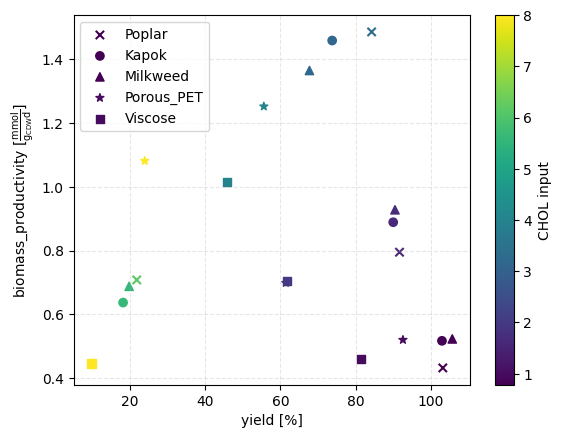

In [107]:
#---------------------------------------
# Load datasets
#---------------------------------------

full_inputs_df = pd.read_excel("Materials Dataset 2.xlsx", sheet_name="Inputs")
full_outputs_df = pd.read_excel("Materials Dataset 2.xlsx", sheet_name="Outputs")

#-----------------------------------------------
# Visualize outputs
#-----------------------------------------------

# Select inputs
inputs_df = full_inputs_df.drop(['moisture_abs'], axis=1)

# Select outputs
output_1 = 'yield'
output_2 = 'biomass_productivity'
outputs_df = full_outputs_df[[output_1, output_1 + '_SD', output_2, output_2 + '_SD']]

# Set color mapping for different materials
material_shapes = {'Poplar': 'x', "Kapok": 'o', 'Milkweed': '^', 'Porous_PET': '*', 'Viscose': 's'}

# Set up CHOL values for the colorbar
chol = full_inputs_df['CHOL_input']
norm = mpl.colors.Normalize(vmin = chol.min(), vmax = chol.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots()

# Plot each material separately
for material, mark in material_shapes.items():
    mask = full_inputs_df['material'] == material

    ax.scatter(
        outputs_df.loc[mask, output_1], 
        outputs_df.loc[mask, output_2],
        c=chol.loc[mask],
        cmap=cmap,
        norm=norm, 
        label=material, 
        marker=mark
    )

# Add colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('CHOL input')

ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlabel(output_1 + ' [%]')
ax.set_ylabel(output_2 + r' [$\frac{\mathrm{mmol}}{\mathrm{g_{CDW} d}}$]')
ax.legend()

plt.show()

In [108]:
X_raw = inputs_df.drop(['material'], axis=1)
Y_raw = outputs_df
df = pd.concat([X_raw, Y_raw], axis=1)
df = shuffle(df, random_state=RSEED).reset_index(drop=True)

In [109]:
input_cols     = ['thickness', 'density', 'porosity', 'CHOL_input']
output_cols    = ['yield', 'biomass_productivity']
output_sd_cols = ['yield_SD', 'biomass_productivity_SD']   # reported experimental SD, same units as output_cols

X_raw    = df[input_cols].values
Y_raw    = df[output_cols].values
Y_sd_raw = df[output_sd_cols].values

print(f"Dataset: {X_raw.shape[0]} experiments, {X_raw.shape[1]} inputs, {Y_raw.shape[1]} outputs")
print(df[input_cols + output_cols + output_sd_cols].describe().round(3))

Dataset: 20 experiments, 4 inputs, 2 outputs
       thickness  density  porosity  CHOL_input    yield  \
count     20.000   20.000    20.000      20.000   20.000   
mean       2.376  209.600    71.620       3.211   65.071   
std        1.750  117.888    10.532       2.352   31.946   
min        0.320   60.000    60.100       0.784    9.699   
25%        0.345   80.000    65.000       1.434   40.348   
50%        3.094  279.000    65.000       2.582   70.737   
75%        4.050  312.000    84.000       4.393   90.786   
max        4.070  317.000    84.000       8.000  105.740   

       biomass_productivity  yield_SD  biomass_productivity_SD  
count                20.000    20.000                   20.000  
mean                  0.830     4.248                    0.110  
std                   0.343     2.507                    0.123  
min                   0.432     0.646                    0.017  
25%                   0.522     2.737                    0.036  
50%                   0.

## 2. Normalisation & Incorporating Experimental Noise

Inputs are normalised to [0, 1] per feature using the observed range. Outputs are
standardised (zero mean, unit variance) rather than left raw.

**Including the known experimental noise.** Every observation has a reported standard deviation
(`yield_SD`, `biomass_productivity_SD`). This is *heteroscedastic, known* measurement noise, there's no reason to let the GP
re-estimate a single global noise level by MLE (which is what happens if you fit a plain
`SingleTaskGP`/`MultiTaskGP` without telling it about the SDs).

BoTorch handles this natively: `SingleTaskGP` and `MultiTaskGP` both accept a `train_Yvar` tensor of
*known* observation **variances**, one per training point. When `train_Yvar` is supplied, BoTorch
swaps the default `GaussianLikelihood` (which learns one noise variance for the whole dataset) for a
`FixedNoiseGaussianLikelihood`, which pins the noise at each point to the provided value instead of
learning it. This is the standard way to fold in known experimental uncertainty, and it also means the
noisy acquisition functions (`qLogNoisyExpectedHypervolumeImprovement`) automatically account for the
fact that some historical points are less trustworthy than others.

- Standardizing `Y`:
1. `train_Yvar` must be a **variance**, not a standard deviation → `Yvar = SD**2`.
2. When standarizing `Y` (subtract the mean, divide by the std), the noise must be rescaled
   consistently: $\mathrm{Var}(Y) \rightarrow \mathrm{Var}(Y)/\sigma_Y^2$, i.e. `train_Yvar_scaled = (SD/Y_std)**2`.

`KroneckerMultiTaskGP` (used in the multi-objective notebook) does **not** accept `train_Yvar`, it
only supports a single learned noise level shared across the joint task covariance. This notebook uses BoTorch's `MultiTaskGP` (the "stacked"/ICM formulation with an explicit task-index column) for the MTGP model instead, since it does support `train_Yvar`.

The Random Forest has no native mechanism for per-point label noise (sklearn trees don't have a
likelihood), so it needs a different treatment — see Model C below.

In [110]:
X_bounds = torch.tensor(
    np.vstack([X_raw.min(0), X_raw.max(0)]), dtype=dtype
)  # shape (2, d)

train_X = normalize(
    torch.tensor(X_raw, dtype=dtype), bounds=X_bounds
)  # shape (n, d), values in [0,1]

train_Y    = torch.tensor(Y_raw, dtype=dtype)          # shape (n, 2), raw units
train_Yvar = torch.tensor(Y_sd_raw, dtype=dtype) ** 2   # shape (n, 2), raw VARIANCE (SD**2)

# ---------------------------------------------------------------------------
# Standardize outputs, and propagate the same scaling to the known noise variances
# ---------------------------------------------------------------------------
Y_mean = train_Y.mean(dim=0)
Y_std  = train_Y.std(dim=0)
train_Y_scaled    = (train_Y - Y_mean) / Y_std
train_Yvar_scaled = train_Yvar / (Y_std ** 2)     # variance rescales by std**2, no mean shift

# Unit cube bounds for acquisition function optimisation
unit_bounds = torch.zeros(2, train_X.shape[1], dtype=dtype)
unit_bounds[1] = 1.0

# Physically possible reference point for the worst case scenario of the outputs
ref_point = (0, 0)
# Standarized reference point
ref_point_scaled = (Tensor(ref_point) - Y_mean) / Y_std

print(f"Reference point: yield={ref_point[0]:.3f}, biomass_productivity={ref_point[1]:.4f}")
print(f"Scaled reference point: yield={ref_point_scaled[0]:.3f}, biomass_productivity={ref_point_scaled[1]:.4f}")
print(f"Median relative noise (SD/mean): yield={np.median(Y_sd_raw[:,0]/Y_raw[:,0]):.1%}, "
      f"biomass_productivity={np.median(Y_sd_raw[:,1]/Y_raw[:,1]):.1%}")

Reference point: yield=0.000, biomass_productivity=0.0000
Scaled reference point: yield=-2.037, biomass_productivity=-2.4194
Median relative noise (SD/mean): yield=6.3%, biomass_productivity=9.3%


## 3.1 Model A — ModelListGP (independent GPs, with known noise)

Two separate `SingleTaskGP`s, one per output — `ModelListGP` batches them together, exactly as
before. The only change from a noise-free version is passing `train_Yvar` into each `SingleTaskGP`:
this fixes the observation noise at each point to the reported experimental variance instead of
estimating a single noise level by maximum likelihood.

In [111]:
def build_model_list_gp(train_X, train_Y, train_Yvar=None):
    """Two independent SingleTaskGPs, one per output, with optional known (fixed) noise."""
    models = []
    for i in range(train_Y.shape[1]):
        yvar_i = None if train_Yvar is None else train_Yvar[:, i:i + 1]
        gp = SingleTaskGP(train_X=train_X, train_Y=train_Y[:, i:i + 1], train_Yvar=yvar_i)
        models.append(gp)
    return ModelListGP(*models)

# --------------------------------------------------------------------
# Initialize and fit model
# --------------------------------------------------------------------
mlgp = build_model_list_gp(train_X, train_Y_scaled, train_Yvar_scaled)
mll_mlgp = SumMarginalLogLikelihood(mlgp.likelihood, mlgp)
fit_gpytorch_mll(mll_mlgp)
print("ModelListGP trained (fixed, known observation noise per point).")

# --------------------------------------------------------------------
# Check posterior at training points
# --------------------------------------------------------------------
mlgp.eval()
with torch.no_grad():
    post = mlgp.posterior(train_X)
    print(f"Posterior mean shape: {post.mean.shape}")  # expect (n, 2)

ModelListGP trained (fixed, known observation noise per point).
Posterior mean shape: torch.Size([20, 2])


### Training quality check

#### Posterior mean vs observed values

The posterior mean (predicted output after training) is plotted vs the actual observed values, with
the GP's own $\pm 2\sigma$ as the y-error bar and the *known experimental* SD as the x-error bar. A
clear linear tendency, with GP uncertainty in the same ballpark as the measurement uncertainty, shows
the model has learned to reproduce the training data without simply overfitting past the noise.

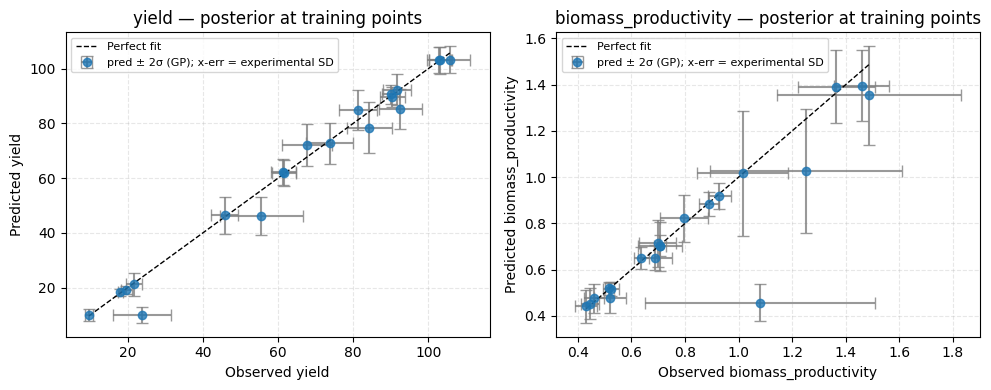

In [112]:
mlgp.eval()
with torch.no_grad():
    post = mlgp.posterior(train_X)
    mean = post.mean * Y_std + Y_mean
    std  = post.variance.sqrt() * Y_std

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    y_obs    = train_Y[:, i].numpy()
    y_obs_sd = Y_sd_raw[:, i]
    y_pred   = mean[:, i]
    y_std    = std[:, i]

    ax.errorbar(y_obs, y_pred, xerr=y_obs_sd, yerr=2 * y_std, fmt='o',
                color='tab:blue', ecolor='grey', capsize=4, alpha=0.8,
                label='pred ± 2σ (GP); x-err = experimental SD')
    lims = [min(y_obs.min(), y_pred.min()), max(y_obs.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect fit')
    ax.set_xlabel(f'Observed {output_cols[i]}')
    ax.set_ylabel(f'Predicted {output_cols[i]}')
    ax.set_title(f'{output_cols[i]} — posterior at training points')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

#### Leave-One-Out cross-validation

For each training point, the GP is refit without it (using its known noise for the *remaining*
points), then used to predict the held-out point. A roughly linear trend shows the model
generalises beyond memorising individual noisy observations.

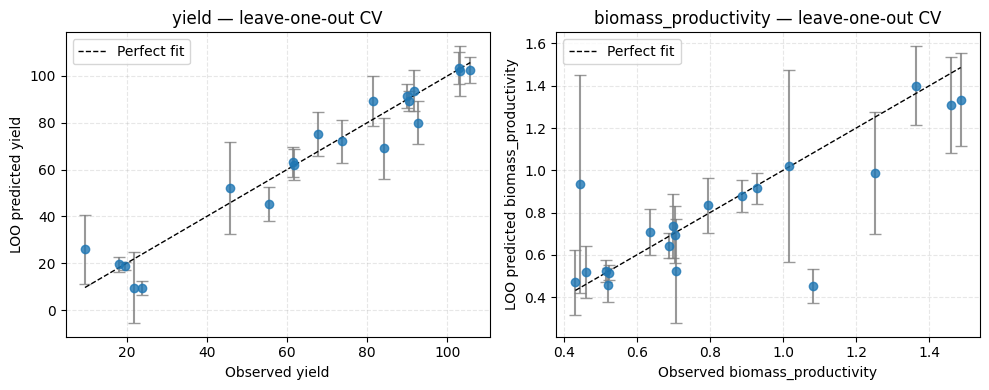

In [113]:
def loo_predictions(train_X, train_Y, train_Yvar, output_idx):
    n = train_X.shape[0]
    loo_means = np.zeros(n)
    loo_stds  = np.zeros(n)
    y    = train_Y[:, output_idx:output_idx + 1]
    yvar = train_Yvar[:, output_idx:output_idx + 1]

    for i in range(n):
        mask = torch.ones(n, dtype=torch.bool)
        mask[i] = False
        X_tr, y_tr, yvar_tr = train_X[mask], y[mask], yvar[mask]
        X_te = train_X[i:i + 1]

        gp = SingleTaskGP(train_X=X_tr, train_Y=y_tr, train_Yvar=yvar_tr)
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)
        gp.eval()
        with torch.no_grad():
            post = gp.posterior(X_te)
            loo_means[i] = post.mean.item()
            loo_stds[i]  = post.variance.sqrt().item()
    return loo_means, loo_stds


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    loo_mean, loo_std = loo_predictions(train_X, train_Y, train_Yvar, i)
    y_obs = train_Y[:, i].numpy()

    ax.errorbar(y_obs, loo_mean, yerr=2 * loo_std, fmt='o',
                color='tab:blue', ecolor='grey', capsize=4, alpha=0.8)
    lims = [min(y_obs.min(), loo_mean.min()), max(y_obs.max(), loo_mean.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect fit')
    ax.set_xlabel(f'Observed {output_cols[i]}')
    ax.set_ylabel(f'LOO predicted {output_cols[i]}')
    ax.set_title(f'{output_cols[i]} — leave-one-out CV')
    ax.legend()
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Note: `SingleTaskGP` standardises `train_Y`/`train_Yvar` internally by default (`outcome_transform=Standardize`), which is why raw (unscaled) `train_Y`/`train_Yvar` can be passed directly here and `post.mean`/`post.variance` already come back in original units.

## 3.3 Model B — MultiTaskGP (correlated MTGP, with known noise)

`MultiTaskGP` implements an ICM-style coregionalization: the joint covariance factorises into a
data kernel over the inputs and a learned task covariance matrix over the outputs, so it can borrow
strength across `yield` and `biomass_productivity` when they're correlated. Unlike
`KroneckerMultiTaskGP`, it works on a "stacked" data layout — one extra column in `X` encodes which
task (output) each row belongs to — and, crucially for this dataset, it accepts `train_Yvar` for
known per-point noise.

**A note on `rank`**: for exactly 2 outputs, `rank=1` is *not* just "the simplest option" — a
rank-1 factorisation of a 2x2 covariance matrix is mathematically forced to imply a correlation of
exactly $\pm 1$ (Cauchy–Schwarz is tight), regardless of what the data say. Since your two outputs
are essentially uncorrelated in the raw data (Pearson $r\approx0$, computed above), rank=1 would
silently impose a spurious strong correlation. `rank=2` (full rank for $m=2$) is used instead so the
task correlation is actually free to be estimated rather than assumed.

In [114]:
def build_mtgp(train_X, train_Y, train_Yvar=None, rank=2):
    """
    MultiTaskGP with ICM coregionalization, stacked ("long") data layout.
    Every training point is duplicated once per output, with an extra task-index
    column appended to X. rank controls the expressivity of the task covariance.
    """
    n, d = train_X.shape
    m = train_Y.shape[1]

    X_stack = train_X.repeat(m, 1)
    task_idx = torch.cat([torch.full((n, 1), i, dtype=train_X.dtype) for i in range(m)], dim=0)
    X_aug = torch.cat([X_stack, task_idx], dim=-1)   # (n*m, d+1), task index is the last column

    Y_stack = torch.cat([train_Y[:, i:i + 1] for i in range(m)], dim=0)          # (n*m, 1)
    Yvar_stack = None
    if train_Yvar is not None:
        Yvar_stack = torch.cat([train_Yvar[:, i:i + 1] for i in range(m)], dim=0)  # (n*m, 1)

    return MultiTaskGP(
        train_X=X_aug, train_Y=Y_stack, train_Yvar=Yvar_stack,
        task_feature=-1, output_tasks=list(range(m)), rank=rank,
    )

# --------------------------------------------------------------------
# Initialize and fit model
# --------------------------------------------------------------------
mtgp = build_mtgp(train_X, train_Y_scaled, train_Yvar_scaled, rank=2)
mll_mtgp = ExactMarginalLogLikelihood(mtgp.likelihood, mtgp)
fit_gpytorch_mll(mll_mtgp)
print("MTGP (MultiTaskGP) trained (fixed, known observation noise per point).")

# --------------------------------------------------------------------
# Inspect the learned task covariance K_f
# --------------------------------------------------------------------
mtgp.eval()
with torch.no_grad():
    # The task-index kernel lives inside covar_module.kernels (a ProductKernel of
    # the data kernel and the task/index kernel); its covar_factor gives the
    # Cholesky-like factor of the learned inter-task covariance K_f.
    task_kernel = [k for k in mtgp.covar_module.kernels if hasattr(k, "covar_factor")][0]
    cf = task_kernel.covar_factor.detach()
    Kf = cf @ cf.T
    print(f"Learned K_f (inter-task covariance):\n{Kf.numpy().round(4)}")

    post = mtgp.posterior(train_X, output_indices=[0, 1])
    print(f"Posterior mean shape: {post.mean.shape}")  # expect (n, 2)

MTGP (MultiTaskGP) trained (fixed, known observation noise per point).
Learned K_f (inter-task covariance):
[[0.461  0.7283]
 [0.7283 1.4504]]
Posterior mean shape: torch.Size([20, 2])


### Training quality check

#### Posterior mean vs observed values

Same check as for ModelListGP: predicted vs observed, with the GP $\pm 2\sigma$ and the known
experimental SD shown side by side.

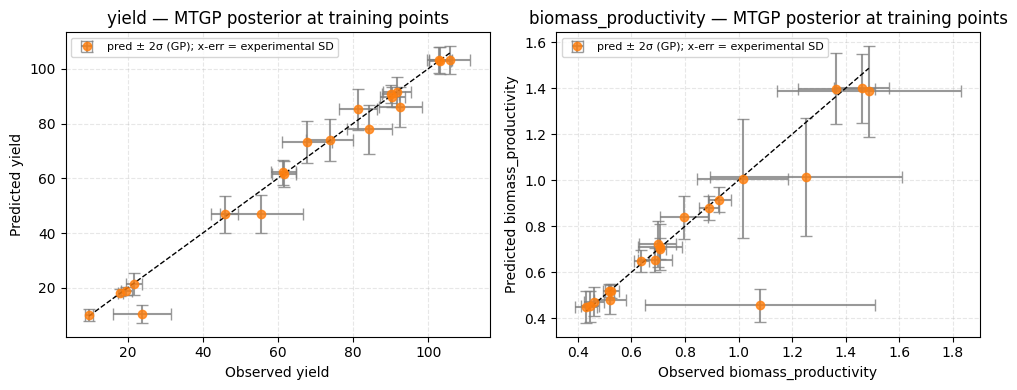

In [115]:
mtgp.eval()
with torch.no_grad():
    post = mtgp.posterior(train_X, output_indices=[0, 1])
    mean = post.mean * Y_std + Y_mean
    std  = post.variance.sqrt() * Y_std

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    y_obs    = train_Y[:, i].numpy()
    y_obs_sd = Y_sd_raw[:, i]
    y_pred   = mean[:, i]

    ax.errorbar(y_obs, y_pred, xerr=y_obs_sd, yerr=2 * std[:, i], fmt='o',
                color='tab:orange', ecolor='grey', capsize=4, alpha=0.8,
                label='pred ± 2σ (GP); x-err = experimental SD')
    lims = [min(y_obs.min(), y_pred.min()), max(y_obs.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel(f'Observed {output_cols[i]}')
    ax.set_ylabel(f'Predicted {output_cols[i]}')
    ax.set_title(f'{output_cols[i]} — MTGP posterior at training points')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 3.4 Model C — Random Forest with Bootstrap Uncertainty + Known Noise

### Why RF uncertainty is not a true posterior

An RF has no built-in probabilistic model. The standard proxy for uncertainty is the **variance of
the per-tree predictions**. This is a frequentist, bootstrap-based estimate — it captures *model
disagreement*, which correlates with aleatoric+epistemic uncertainty in practice, but is **not** a
Bayesian posterior. In low-data or extrapolation regimes it tends to underestimate uncertainty (trees
agree, but are all wrong in the same way outside the training hull).

### Incorporating the known experimental noise

sklearn's `RandomForestRegressor` has no likelihood, so there's no exact equivalent of `train_Yvar`.
Two standard, complementary tricks are used here instead:

1. **Inverse-variance sample weighting at fit time.** `RandomForestRegressor.fit(..., sample_weight=...)`
   lets noisier points contribute less to how the trees choose their splits, via
   $w_i = 1/\sigma_i^2$ (points you trust more get more influence over tree structure).
2. **An explicit noise floor added at prediction time.** Sample weighting alone doesn't stop trees from
   reporting *near-zero* variance in a region purely because they interpolate it consistently — it
   doesn't know that the underlying observation itself was noisy. So the total predictive variance
   reported by the wrapper is `Var_tree (epistemic, disagreement across trees) + Var_floor (aleatoric,
   the mean known experimental variance for that output)`. This mirrors how a GP's predictive variance
   is (posterior variance) + (observation noise): it's an approximation — a genuinely
   position-dependent aleatoric term (e.g. nearest-neighbour noise) would be more accurate, but this
   is a reasonable, cheap floor.

Because the two outputs have different noise levels, a single joint multi-output RF (as in the
noise-free version) can't apply output-specific weights, so this version fits **one RF per output**
instead of one shared multi-output RF.

We wrap this in a custom `Model` that exposes a `posterior()` method returning a
`GPyTorchPosterior`-compatible object, so BoTorch acquisition functions can consume it.

In [116]:
from torch.distributions import MultivariateNormal as TorchMVN

class RFPosterior(Posterior):
    """
    Minimal BoTorch-compatible posterior backed by RF tree-variance.

    _mean:  (batch, q, m)
    _variance: (batch, q, m)  — diagonal only, trees assumed independent per output
    """
    def __init__(self, mean: Tensor, variance: Tensor):
        super().__init__()
        self._mean = mean
        self._variance = variance

    @property
    def device(self) -> torch.device:
        return self._mean.device

    @property
    def dtype(self) -> torch.dtype:
        return self._mean.dtype

    @property
    def mean(self) -> Tensor:
        return self._mean

    @property
    def variance(self) -> Tensor:
        return self._variance

    @property
    def base_sample_shape(self) -> torch.Size:
        # Shape of the "event" dimension — one independent normal per output per candidate
        return torch.Size([self._mean.shape[-2], self._mean.shape[-1]])  # (q, m)

    @property
    def batch_range(self) -> tuple[int, int]:
        return (0, 0)

    @property
    def batch_shape(self) -> torch.Size:
        # Everything in _mean except the last two dims (q, m) is batch
        return self._mean.shape[:-2]

    def _extended_shape(self, sample_shape: torch.Size = torch.Size()) -> torch.Size:
        return sample_shape + self._mean.shape

    def rsample_from_base_samples(
        self, sample_shape: torch.Size, base_samples: torch.Tensor
    ) -> torch.Tensor:
        std = self._variance.clamp(min=1e-9).sqrt()
        # base_samples: (*sample_shape, *batch, q, m)
        # mean/std:     (*batch, q, m)
        # Align by expanding mean/std to match all leading dims of base_samples
        extra_dims = base_samples.dim() - self._mean.dim()
        mean = self._mean
        for _ in range(extra_dims):
            mean = mean.unsqueeze(0)
            std = std.unsqueeze(0)
        return mean + base_samples * std

    def rsample(self, sample_shape: torch.Size = torch.Size()) -> Tensor:
        """
        Draw reparameterized samples: mu + eps * sigma, eps ~ N(0,1).
        Returns shape (*sample_shape, *batch_shape, q, m).
        This is what Monte Carlo acquisition functions (qNEHVI) integrate over.
        """
        std = self._variance.clamp(min=1e-9).sqrt()
        eps = torch.randn(
            *sample_shape, *self._mean.shape,
            dtype=self._mean.dtype, device=self._mean.device
        )
        return self._mean + eps * std


class RandomForestModel(Model):
    """
    BoTorch Model wrapper around one sklearn RandomForestRegressor per output.
    Uncertainty = tree-ensemble variance (epistemic) + known-noise floor (aleatoric).
    """
    def __init__(self, train_X: Tensor, train_Y: Tensor, train_Yvar: Tensor = None, **rf_kwargs):
        super().__init__()
        self._num_outputs = train_Y.shape[-1]
        X_np = train_X.detach().cpu().numpy()
        Y_np = train_Y.detach().cpu().numpy()

        self.rfs = []
        self._noise_floor = np.zeros(self._num_outputs)
        for i in range(self._num_outputs):
            rf = RandomForestRegressor(
                n_estimators=rf_kwargs.get('n_estimators', 500),
                max_depth=rf_kwargs.get('max_depth', None),
                random_state=RSEED,
            )
            sample_weight = None
            if train_Yvar is not None:
                var_i = train_Yvar[:, i].detach().cpu().numpy()
                sample_weight = 1.0 / np.clip(var_i, 1e-8, None)   # inverse-variance weighting
                sample_weight = sample_weight / sample_weight.mean()  # normalise for stability
                self._noise_floor[i] = var_i.mean()                # aleatoric floor for unseen X
            rf.fit(X_np, Y_np[:, i], sample_weight=sample_weight)
            self.rfs.append(rf)

        self._dtype = train_X.dtype
        self._device = train_X.device

    @property
    def num_outputs(self) -> int:
        return self._num_outputs

    def posterior(self, X: Tensor, **kwargs) -> RFPosterior:
        """
        Compute tree-ensemble mean/variance + noise floor.
        X shape: (..., q, d)  — arbitrary batch dimensions + q candidates
        Returns posterior with mean/variance shape (..., q, m).
        """
        batch_shape = X.shape[:-2]
        q, d = X.shape[-2], X.shape[-1]
        X_flat = X.reshape(-1, d).detach().cpu().numpy()  # (batch*q, d)

        means, varis = [], []
        for i, rf in enumerate(self.rfs):
            tree_preds = np.stack([tree.predict(X_flat) for tree in rf.estimators_], axis=0)  # (n_trees, batch*q)
            means.append(tree_preds.mean(axis=0))
            varis.append(tree_preds.var(axis=0) + self._noise_floor[i])
        mean_np = np.stack(means, axis=-1)   # (batch*q, m)
        var_np  = np.stack(varis, axis=-1)   # (batch*q, m)

        m = self._num_outputs
        mean = torch.tensor(mean_np, dtype=self._dtype, device=self._device).reshape(*batch_shape, q, m)
        var  = torch.tensor(var_np,  dtype=self._dtype, device=self._device).reshape(*batch_shape, q, m)

        return RFPosterior(mean, var)

# --------------------------------------------------------------------
# Initialize and fit model
# --------------------------------------------------------------------
rf_model = RandomForestModel(train_X, train_Y_scaled, train_Yvar_scaled, n_estimators=500)
print("RF model trained (per-output, inverse-variance sample weighting + noise floor).")

# Sanity check
test_post = rf_model.posterior(train_X[:3].unsqueeze(0))  # batch (1, 3, d)
print(f"RF posterior mean shape: {test_post.mean.shape}")  # (1, 3, 2)

RF model trained (per-output, inverse-variance sample weighting + noise floor).
RF posterior mean shape: torch.Size([1, 3, 2])


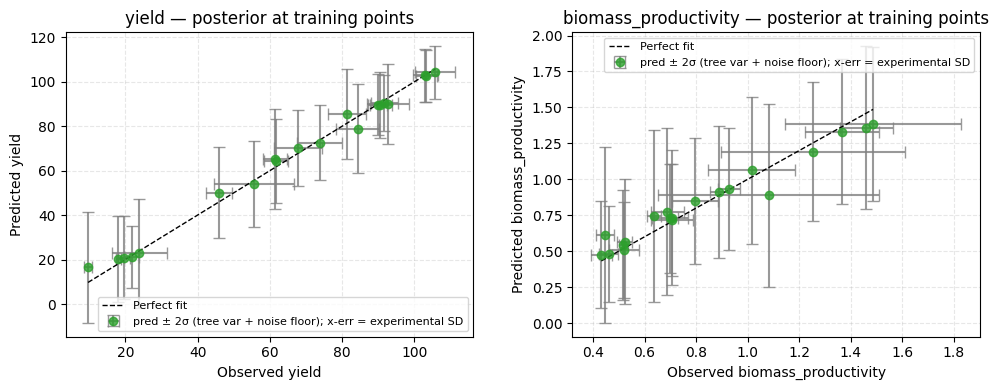

In [117]:
with torch.no_grad():
    post = rf_model.posterior(train_X)
    mean = post.mean * Y_std + Y_mean
    std  = post.variance.sqrt() * Y_std

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    y_obs    = train_Y[:, i].numpy()
    y_obs_sd = Y_sd_raw[:, i]
    y_pred   = mean[:, i]
    y_std    = std[:, i]

    ax.errorbar(y_obs, y_pred, xerr=y_obs_sd, yerr=2 * y_std, fmt='o',
                color='tab:green', ecolor='grey', capsize=4, alpha=0.8,
                label='pred ± 2σ (tree var + noise floor); x-err = experimental SD')
    lims = [min(y_obs.min(), y_pred.min()), max(y_obs.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect fit')
    ax.set_xlabel(f'Observed {output_cols[i]}')
    ax.set_ylabel(f'Predicted {output_cols[i]}')
    ax.set_title(f'{output_cols[i]} — posterior at training points')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 6. Batch BO — qLogNEHVI for all three models

`qNEHVI` (q-Log Noisy Expected Hypervolume Improvement) is the acquisition function of choice here:
- **Multi-objective**: optimises over a Pareto frontier, not a scalarised objective
- **Noisy**: accounts for observation noise in the base samples (uses the full joint posterior) —
  this is exactly where the `train_Yvar` we fed into the GPs pays off: the acquisition function now
  knows that some historical points are less trustworthy than others.
- **Batch**: selects q=3 candidates jointly, accounting for inter-candidate dependencies via MC integration

For all three models we use the same `qLogNEHVI` class — the RF model's `rsample` method (Gaussian
reparameterisation over tree variance + noise floor) provides the MC samples needed.

In [118]:
from botorch.utils.multi_objective.box_decompositions.non_dominated import (
    FastNondominatedPartitioning,
)
from botorch.utils.multi_objective.pareto import is_non_dominated

BATCH_SIZE = 3       # number of new experiments to suggest
NUM_RESTARTS = 10    # random restarts for acq optimisation
RAW_SAMPLES = 512    # initial MC samples for candidate seeding
MC_SAMPLES = 128     # samples for qNEHVI integration

ref_point_tensor = torch.tensor(ref_point, dtype=dtype)


def suggest_experiments(model, train_X, train_Y, ref_point_tensor, label="model"):
    """
    Run one round of batch BO with qLogNEHVI.
    Returns suggested candidates in the *original* (unnormalised) input space.
    """
    with manual_seed(RSEED):

        # --------------------------------------------------------------------
        # Compute acquisition function
        # --------------------------------------------------------------------
        if isinstance(model, RandomForestModel):
            # Partition the current Pareto front for the hypervolume computation
            partitioning = FastNondominatedPartitioning(ref_point=ref_point_tensor, Y=train_Y)
            acq = qLogExpectedHypervolumeImprovement(
                model=model,
                ref_point=ref_point_tensor,
                partitioning=partitioning,
                sampler=SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES])),
            )
        else:
            acq = qLogNoisyExpectedHypervolumeImprovement(
                model=model,
                ref_point=ref_point_tensor,
                X_baseline=train_X,
                sampler=SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES])),
            )

        # --------------------------------------------------------------------
        # Optimize the objective and suggest q experiments
        # --------------------------------------------------------------------
        candidates_norm, acq_value = optimize_acqf(
            acq_function=acq,
            bounds=unit_bounds,
            q=BATCH_SIZE,
            num_restarts=NUM_RESTARTS,
            raw_samples=RAW_SAMPLES,
            options={"batch_limit": 5, "maxiter": 200},
        )

    # --------------------------------------------------------------------
    # Denormalise candidates back to original input ranges
    # --------------------------------------------------------------------
    candidates_orig = unnormalize(candidates_norm.detach(), bounds=X_bounds)

    print(f"\n{'='*55}")
    print(f"  {label} — suggested experiments")
    print(f"{'='*55}")
    df_sugg = pd.DataFrame(candidates_orig.numpy(), columns=input_cols)
    df_sugg.index = [f"Suggestion_{i+1}" for i in range(BATCH_SIZE)]
    print(df_sugg.round(4))
    print(f"  qLogNEHVI value: {acq_value.item():.4f}")
    return candidates_orig, df_sugg


def suggest_experiments_rf(rf_model, X_bounds, n_candidates=10000, batch_size=3):
    rng = check_random_state(RSEED)
    d = X_bounds.shape[1]

    # 1. Sample candidates uniformly in [0,1]^d (normalised space)
    X_cands_norm = rng.uniform(0, 1, size=(n_candidates, d))

    # 2. Collect per-tree predictions on normalised inputs, per output, + noise floor
    means, stds = [], []
    for i, rf in enumerate(rf_model.rfs):
        tree_preds = np.stack([t.predict(X_cands_norm) for t in rf.estimators_], axis=0)  # (n_trees, n_candidates)
        means.append(tree_preds.mean(axis=0))
        stds.append(np.sqrt(tree_preds.var(axis=0) + rf_model._noise_floor[i]))
    Y_cands_mean = np.stack(means, axis=-1)  # (n_candidates, 2)
    Y_cands_std  = np.stack(stds, axis=-1)   # (n_candidates, 2)

    # 3. Find Pareto-non-dominated candidates (based on mean predictions)
    pareto_mask = is_non_dominated(torch.tensor(Y_cands_mean, dtype=dtype)).numpy()

    X_pareto      = X_cands_norm[pareto_mask]
    Y_pareto_mean = Y_cands_mean[pareto_mask]
    Y_pareto_std  = Y_cands_std[pareto_mask]
    print(f"  Pareto front size among candidates: {X_pareto.shape[0]}")

    # 4. Greedily select batch_size points with max spread in output space
    selected  = []
    remaining = list(range(len(X_pareto)))

    first = np.argmax(Y_pareto_mean[:, 0])
    selected.append(first)
    remaining.remove(first)

    while len(selected) < min(batch_size, len(X_pareto)):
        dists = np.array([
            min(np.linalg.norm(Y_pareto_mean[i] - Y_pareto_mean[s]) for s in selected)
            for i in remaining
        ])
        next_idx = remaining[np.argmax(dists)]
        selected.append(next_idx)
        remaining.remove(next_idx)

    X_sel_norm = X_pareto[selected]
    Y_sel_mean = Y_pareto_mean[selected]
    Y_sel_std  = Y_pareto_std[selected]

    # 5. Unnormalise only for display
    X_sel_orig = unnormalize(
        torch.tensor(X_sel_norm, dtype=dtype), bounds=X_bounds
    ).numpy()

    print(f"\n{'='*55}")
    print(f"  RandomForest — suggested experiments (original space)")
    print(f"{'='*55}")
    df_sugg = pd.DataFrame(X_sel_orig, columns=input_cols)
    df_sugg.index = [f"Suggestion_{i+1}" for i in range(len(selected))]
    df_sugg['pred_yield']     = Y_sel_mean[:, 0].round(3)
    df_sugg['pred_std_yield'] = Y_sel_std[:, 0].round(3)
    df_sugg['pred_prod']      = Y_sel_mean[:, 1].round(4)
    df_sugg['pred_std_prod']  = Y_sel_std[:, 1].round(4)
    print(df_sugg.round(4))

    return torch.tensor(X_sel_orig, dtype=dtype), df_sugg

In [119]:
# --- Model A: ModelListGP ---
cands_mlgp, df_mlgp = suggest_experiments(mlgp, train_X, train_Y_scaled, ref_point_scaled, label="ModelListGP (independent GPs)")


  ModelListGP (independent GPs) — suggested experiments
              thickness   density  porosity  CHOL_input
Suggestion_1      4.070  317.0000    79.551      3.0067
Suggestion_2      4.070   96.3895    60.100      3.0200
Suggestion_3      0.815  317.0000    60.100      2.9811
  qLogNEHVI value: -0.4953


In [120]:
# --- Model B: MultiTaskGP ---
cands_mtgp, df_mtgp = suggest_experiments(mtgp, train_X, train_Y_scaled, ref_point_scaled, label="MultiTaskGP (MTGP)")


  MultiTaskGP (MTGP) — suggested experiments
              thickness  density  porosity  CHOL_input
Suggestion_1       4.07     60.0    60.100      3.0765
Suggestion_2       0.32    317.0    78.154      0.7840
Suggestion_3       0.32    317.0    60.100      3.0904
  qLogNEHVI value: -0.3095


In [121]:
#--- Model C: RandomForest ---

cands_rf, df_rf = suggest_experiments_rf(rf_model, X_bounds)

  Pareto front size among candidates: 15

  RandomForest — suggested experiments (original space)
              thickness   density  porosity  CHOL_input  pred_yield  \
Suggestion_1     3.3708  298.8019   64.8675      0.8644       1.181   
Suggestion_2     2.6244  289.3646   61.9792      3.1719       0.361   
Suggestion_3     3.6680  316.5639   64.4375      1.6527       0.769   

              pred_std_yield  pred_prod  pred_std_prod  
Suggestion_1           0.186    -0.9082         0.5603  
Suggestion_2           0.305     1.6215         0.7779  
Suggestion_3           0.222     0.2740         0.6506  


## 7. Compare Suggestions in Output Space

We predict the outputs at the suggested inputs and overlay them on the observed Pareto front.

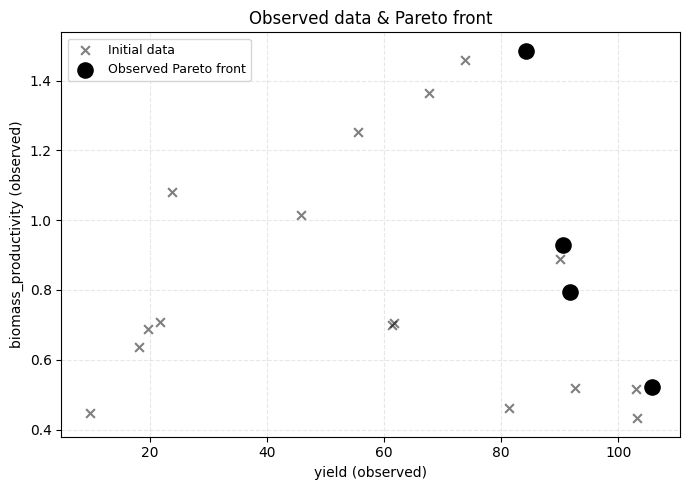

In [122]:
from botorch.utils.multi_objective.pareto import is_non_dominated

def predict_outputs(model, candidates_orig, label):
    """Predict mean outputs at suggested inputs with the corresponding uncertainty."""
    X_norm = normalize(candidates_orig, bounds=X_bounds)
    if isinstance(model, RandomForestModel):
        # ----------------------------------------------------------------------------
        # For Random Forest, uncertainty = tree variance + known-noise floor, per output
        # ----------------------------------------------------------------------------
        means, stds = [], []
        for i, rf in enumerate(model.rfs):
            tree_preds = np.stack([tree.predict(X_norm.numpy()) for tree in rf.estimators_], axis=0)
            means.append(tree_preds.mean(axis=0))
            stds.append(np.sqrt(tree_preds.var(axis=0) + model._noise_floor[i]))
        mean_scaled = np.stack(means, axis=-1)
        std_scaled  = np.stack(stds, axis=-1)
        # Scale to original units
        mean = mean_scaled * Y_std.numpy() + Y_mean.numpy()
        std  = std_scaled * Y_std.numpy()
        return mean, std
    else:
        model.eval()
        with torch.no_grad():
            post = model.posterior(X_norm)
            mean = post.mean * Y_std + Y_mean
            std  = post.variance.sqrt() * Y_std
        return mean, std


pred_mlgp, pred_uncert_mlgp = predict_outputs(mlgp,     cands_mlgp, "ModelListGP")
pred_mtgp, pred_uncert_mtgp = predict_outputs(mtgp,     cands_mtgp, "MTGP")
pred_rf,   pred_uncert_rf   = predict_outputs(rf_model, cands_rf,   "RF")

# Pareto front of observed data
pareto_mask = is_non_dominated(train_Y)
pareto_Y = train_Y[pareto_mask].numpy()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(Y_raw[:, 0], Y_raw[:, 1],
           c='black', marker='x', s=40, alpha=0.5, label='Initial data')
ax.scatter(pareto_Y[:, 0], pareto_Y[:, 1],
           c='black', marker='o', s=120, zorder=5, label='Observed Pareto front')
ax.set_xlabel('yield (observed)')
ax.set_ylabel('biomass_productivity (observed)')
ax.set_title('Observed data & Pareto front')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

preds  = [pred_mlgp.detach().numpy() if torch.is_tensor(pred_mlgp) else pred_mlgp,
          pred_mtgp.detach().numpy() if torch.is_tensor(pred_mtgp) else pred_mtgp,
          pred_rf]
uncert = [pred_uncert_mlgp.detach().numpy() if torch.is_tensor(pred_uncert_mlgp) else pred_uncert_mlgp,
          pred_uncert_mtgp.detach().numpy() if torch.is_tensor(pred_uncert_mtgp) else pred_uncert_mtgp,
          pred_uncert_rf]
labels = ['ModelListGP', 'MTGP', 'RF']
colors = ['tab:blue', 'tab:orange', 'tab:green']
m = 's'


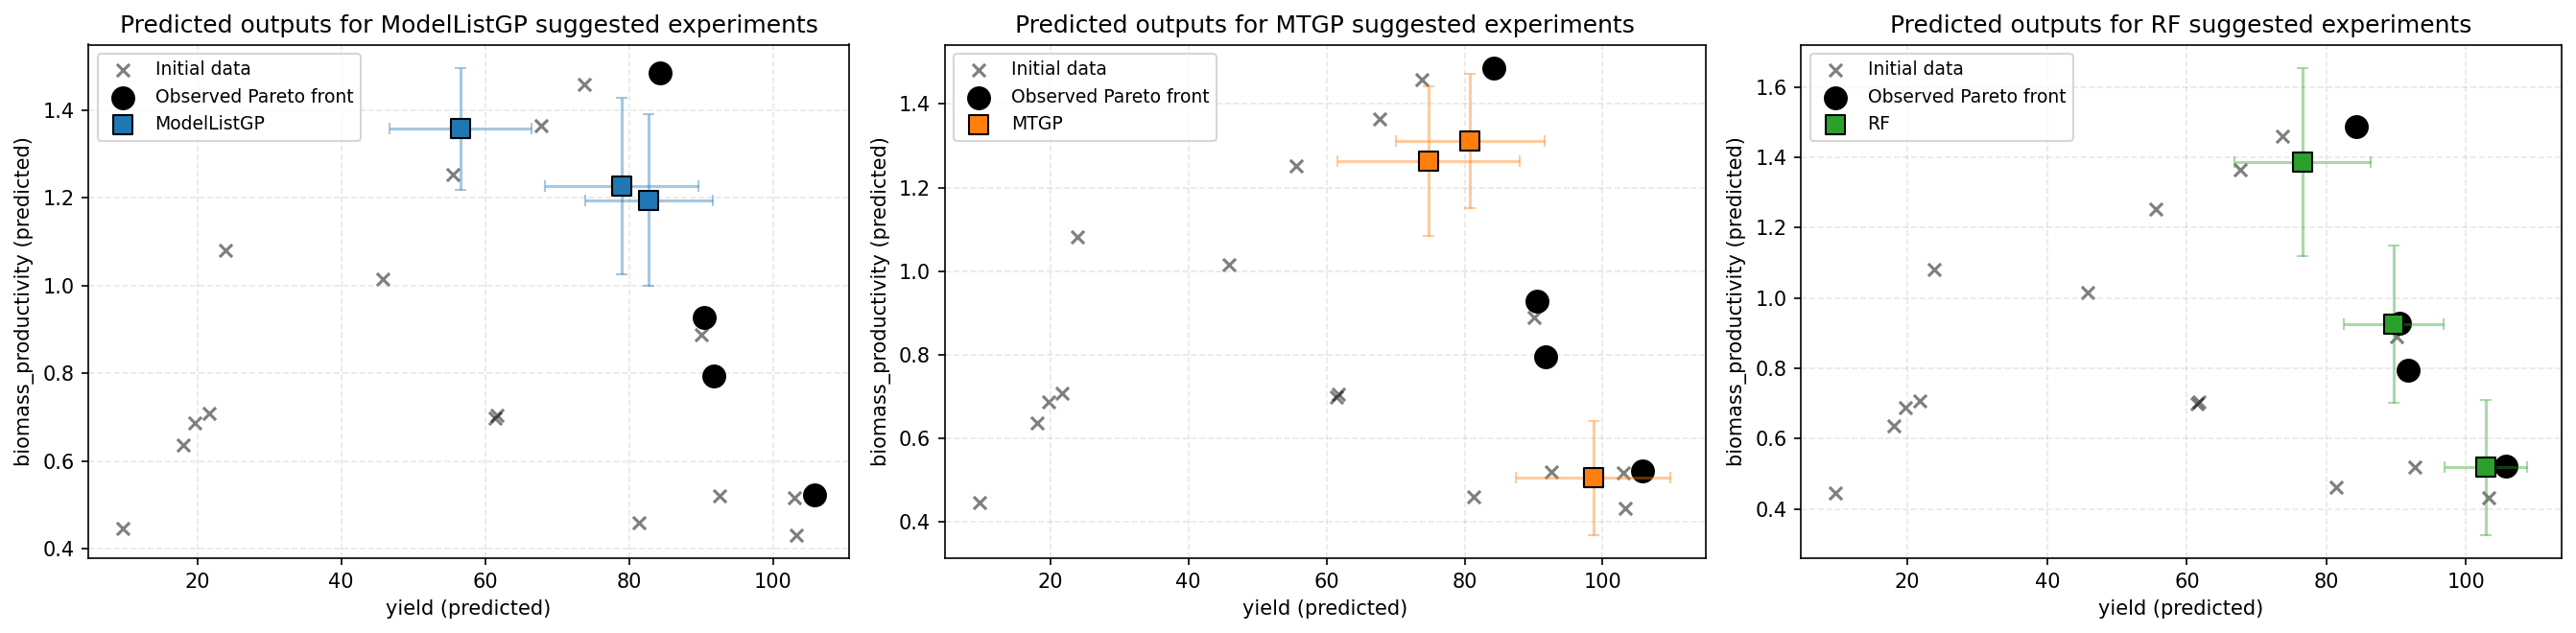

In [123]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5), dpi=150)

for k in range(3):
    ax[k].scatter(Y_raw[:, 0], Y_raw[:, 1], c='black', marker='x', s=40, alpha=0.5, label='Initial data')
    ax[k].scatter(pareto_Y[:, 0], pareto_Y[:, 1], c='black', marker='o', s=120, zorder=5, label='Observed Pareto front')

    ax[k].scatter(preds[k][:, 0], preds[k][:, 1], marker=m, c=colors[k], s=100, edgecolors='black', zorder=10, label=labels[k])
    ax[k].errorbar(preds[k][:, 0], preds[k][:, 1], xerr=uncert[k][:, 0], yerr=uncert[k][:, 1],
                    fmt='none', ecolor=colors[k], alpha=0.4, capsize=3, capthick=1, zorder=9)

    ax[k].legend(fontsize=9)
    ax[k].set_xlabel('yield (predicted)')
    ax[k].set_ylabel('biomass_productivity (predicted)')
    ax[k].set_title(f'Predicted outputs for {labels[k]} suggested experiments')
    ax[k].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 8. Summary Table

In [124]:
def summary_df(df_sugg, pred, pred_uncert, model_name):
    d = df_sugg.copy()
    d.insert(0, 'model', model_name)
    d['pred_yield']        = pred[:, 0].round(3)
    d['pred_uncert_yield'] = pred_uncert[:, 0].round(3)
    d['pred_prod']         = pred[:, 1].round(4)
    d['pred_uncert_prod']  = pred_uncert[:, 1].round(4)
    return d

summary = pd.concat([
    summary_df(df_mlgp, preds[0], uncert[0], 'ModelListGP'),
    summary_df(df_mtgp, preds[1], uncert[1], 'MTGP'),
    summary_df(df_rf,   preds[2], uncert[2], 'RF'),
])
print(summary.to_string())

                    model  thickness     density   porosity  CHOL_input  pred_yield  pred_uncert_yield  pred_prod  pred_uncert_prod  pred_std_yield  pred_std_prod
Suggestion_1  ModelListGP   4.070000  317.000000  79.551035    3.006713      56.592              9.825     1.3576            0.1387             NaN            NaN
Suggestion_2  ModelListGP   4.070000   96.389512  60.100000    3.019972      78.957             10.687     1.2271            0.2008             NaN            NaN
Suggestion_3  ModelListGP   0.814958  317.000000  60.100000    2.981084      82.746              8.827     1.1950            0.1958             NaN            NaN
Suggestion_1         MTGP   4.070000   60.000000  60.100000    3.076465      74.782             13.167     1.2630            0.1791             NaN            NaN
Suggestion_2         MTGP   0.320000  317.000000  78.153980    0.784000      98.664             11.210     0.5056            0.1362             NaN            NaN
Suggestion_3         M

In [ ]:
# Raw original input values
inputs_df[['material', 'thickness', 'density', 'porosity']].drop_duplicates(subset='material').reset_index(drop=True)

,material,thickness,density,porosity
0,Poplar,3.094,279,60.1
1,Kapok,4.050,312,65.0
2,Milkweed,4.070,317,65.0
3,Viscose,0.320,60,84.0
4,Porous_PET,0.345,80,84.0
